# Analyse du Risque de Crédit — Polish Companies Bankruptcy Prediction

## Analyse Comparative Entre Les Modèles De Rating De Risque De Crédit
**Projet de Fin d'Année — Bank of Africa, Business Center Agadir**

---

### Dataset Description
This notebook analyzes the **Polish Companies Bankruptcy** dataset from the UCI ML Repository,
containing financial data of Polish companies collected between **2000 and 2013**.

- **Source**: [UCI ML Repository](https://archive-beta.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) / [Kaggle](https://www.kaggle.com/datasets/stealthtechnologies/predict-bankruptcy-in-poland/data)
- **Files**: 5 ARFF files — `1year.arff` to `5year.arff` (1 to 5 years before bankruptcy)
- **Features**: 64 financial ratios per company
- **Target**: `class` (0=not bankrupt, 1=bankrupt)
- **Problem Type**: Binary Classification (highly imbalanced: 3.9–6.9% bankruptcy)
- **Period**: 2000–2013

### Unique Aspect
The 5 files represent different **prediction horizons**: predicting bankruptcy 1, 2, 3, 4, or 5 years
in advance. This allows us to study how model performance **degrades** as the prediction horizon increases.

### Altman Z-Score Applicability
The dataset contains **all 5 Altman Z-Score components**:
- A3 = Working Capital / Total Assets
- A6 = Retained Earnings / Total Assets
- A7 = EBIT / Total Assets
- A8 = Book Value of Equity / Total Liabilities (proxy for Market Value / Debt)
- A9 = Sales / Total Assets

### Models Applied (4 Paradigms)
1. **Classical Econometric**: Logistic Regression, Probit, LDA, Altman Z-Score
2. **Machine Learning**: XGBoost, LightGBM, Random Forest, SVM, kNN, CART, MLP
3. **Structural & Market-Based**: Merton / KMV (N/A)
4. **Dynamic Stochastic**: Cox PH (partial — using horizon as time proxy)

## Setup

In [ ]:
import subprocess, sys
for pkg in ['lightgbm', 'shap']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import shap
from scipy import stats
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(12,6); plt.rcParams['font.size']=12
print('Libraries loaded.')

Libraries loaded.


---
## Phase 1 — Modeling Scope Framing

| Dimension | Description |
|---|---|
| **Scoring Type** | Corporate bankruptcy prediction |
| **Population** | Polish companies (2000–2013) |
| **Time Horizon** | 5 prediction horizons (1–5 years before bankruptcy) |
| **Features** | 64 financial ratios (profitability, liquidity, leverage, activity) |
| **Target** | Binary: bankrupt (1) vs. non-bankrupt (0) |
| **Imbalance** | 3.9%–6.9% bankruptcy rate depending on horizon |

---
## Phase 2 — Data Preparation and Cleansing
### Load all 5 time horizons

In [3]:
# Load all 5 ARFF files
dfs = {}
for i in range(1, 6):
    data, meta = arff.loadarff(f'{i}year.arff')
    df = pd.DataFrame(data)
    df['class'] = df['class'].apply(lambda x: int(x))
    dfs[i] = df
    bankrupt = (df['class'] == 1).sum()
    print(f'{i}-year horizon: {df.shape[0]:,} companies, {df.shape[1]} features, '
          f'{bankrupt} bankrupt ({bankrupt/len(df):.2%})')

print(f'\nTotal across all horizons: {sum(len(d) for d in dfs.values()):,} observations')

1-year horizon: 7,027 companies, 65 features, 271 bankrupt (3.86%)
2-year horizon: 10,173 companies, 65 features, 400 bankrupt (3.93%)
3-year horizon: 10,503 companies, 65 features, 495 bankrupt (4.71%)
4-year horizon: 9,792 companies, 65 features, 515 bankrupt (5.26%)
5-year horizon: 5,910 companies, 65 features, 410 bankrupt (6.94%)

Total across all horizons: 43,405 observations


### Primary analysis on 1-year horizon (most predictive)

In [4]:
df = dfs[1].copy()
target_col = 'class'
feature_cols = [c for c in df.columns if c != target_col]

# Rename columns from Attr1..Attr64 to A1..A64 for readability
rename_map = {f'Attr{i}': f'A{i}' for i in range(1, 65)}
df = df.rename(columns=rename_map)
feature_cols = [rename_map.get(c, c) for c in feature_cols]

print(f'1-year horizon: {df.shape[0]:,} companies, {len(feature_cols)} features')
print(f'Bankruptcy rate: {df[target_col].mean():.2%}')

1-year horizon: 7,027 companies, 64 features
Bankruptcy rate: 3.86%


In [5]:
# Missing values
missing = df.isnull().sum()
n_missing_cols = (missing > 0).sum()
print(f'Columns with missing values: {n_missing_cols}')
if n_missing_cols > 0:
    print(missing[missing > 0].sort_values(ascending=False).head(10))

# Impute with median
for c in feature_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# Handle inf
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

print(f'After cleaning: {df.isnull().sum().sum()} missing, {np.isinf(df[feature_cols]).sum().sum()} inf')

Columns with missing values: 49
A37    2740
A21    1622
A27     311
A60     135
A45     134
A24     124
A41      84
A11      39
A32      38
A54      34
dtype: int64
After cleaning: 0 missing, 0 inf


---
## Phase 3 — Sampling

In [40]:
X = df[feature_cols]; y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Clean X and y together BEFORE scaling
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

y_train = y_train.replace([np.inf, -np.inf], np.nan)
y_test = y_test.replace([np.inf, -np.inf], np.nan)

# Remove rows with NaN in either X or y
mask_train = ~(X_train.isna().any(axis=1) | y_train.isna())
mask_test = ~(X_test.isna().any(axis=1) | y_test.isna())

X_train = X_train[mask_train]
y_train = y_train[mask_train]
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Fill remaining NaN with train median
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

print(f'Train: {X_train.shape[0]:,} ({y_train.mean():.2%} bankrupt)\nTest: {X_test.shape[0]:,} ({y_test.mean():.2%} bankrupt)')

Train: 4,918 (3.86% bankrupt)
Test: 2,109 (3.84% bankrupt)


---
## Phase 4 — Variable Analysis

In [41]:
# Key attribute descriptions (from attributes.txt)
attr_desc = {
    'A1': 'net profit / total assets',
    'A2': 'total liabilities / total assets',
    'A3': 'working capital / total assets',
    'A6': 'retained earnings / total assets',
    'A7': 'EBIT / total assets',
    'A8': 'book value of equity / total liabilities',
    'A9': 'sales / total assets',
    'A4': 'current assets / short-term liabilities',
    'A29': 'logarithm of total assets',
    'A48': 'EBITDA / total assets'
}
print('Key financial ratios:')
for k, v in attr_desc.items():
    print(f'  {k:5s}: {v}')

Key financial ratios:
  A1   : net profit / total assets
  A2   : total liabilities / total assets
  A3   : working capital / total assets
  A6   : retained earnings / total assets
  A7   : EBIT / total assets
  A8   : book value of equity / total liabilities
  A9   : sales / total assets
  A4   : current assets / short-term liabilities
  A29  : logarithm of total assets
  A48  : EBITDA / total assets


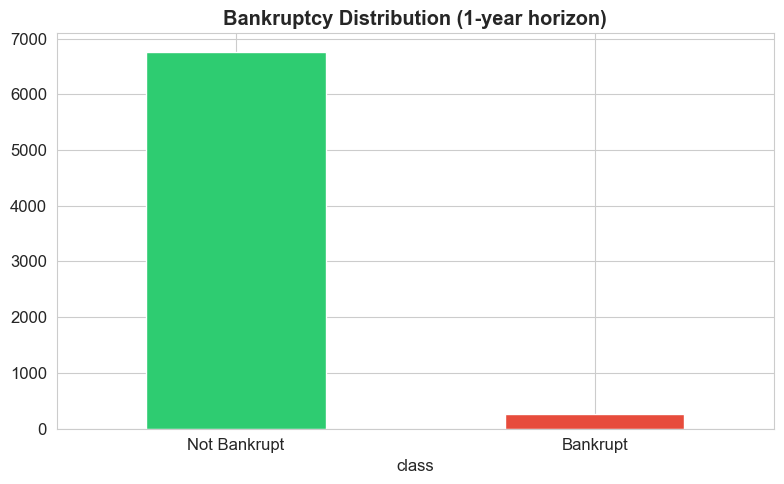

In [42]:
# Distribution of target
fig, ax = plt.subplots(figsize=(8, 5))
df[target_col].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title('Bankruptcy Distribution (1-year horizon)', fontweight='bold')
ax.set_xticklabels(['Not Bankrupt','Bankrupt'], rotation=0)
plt.tight_layout(); plt.show()

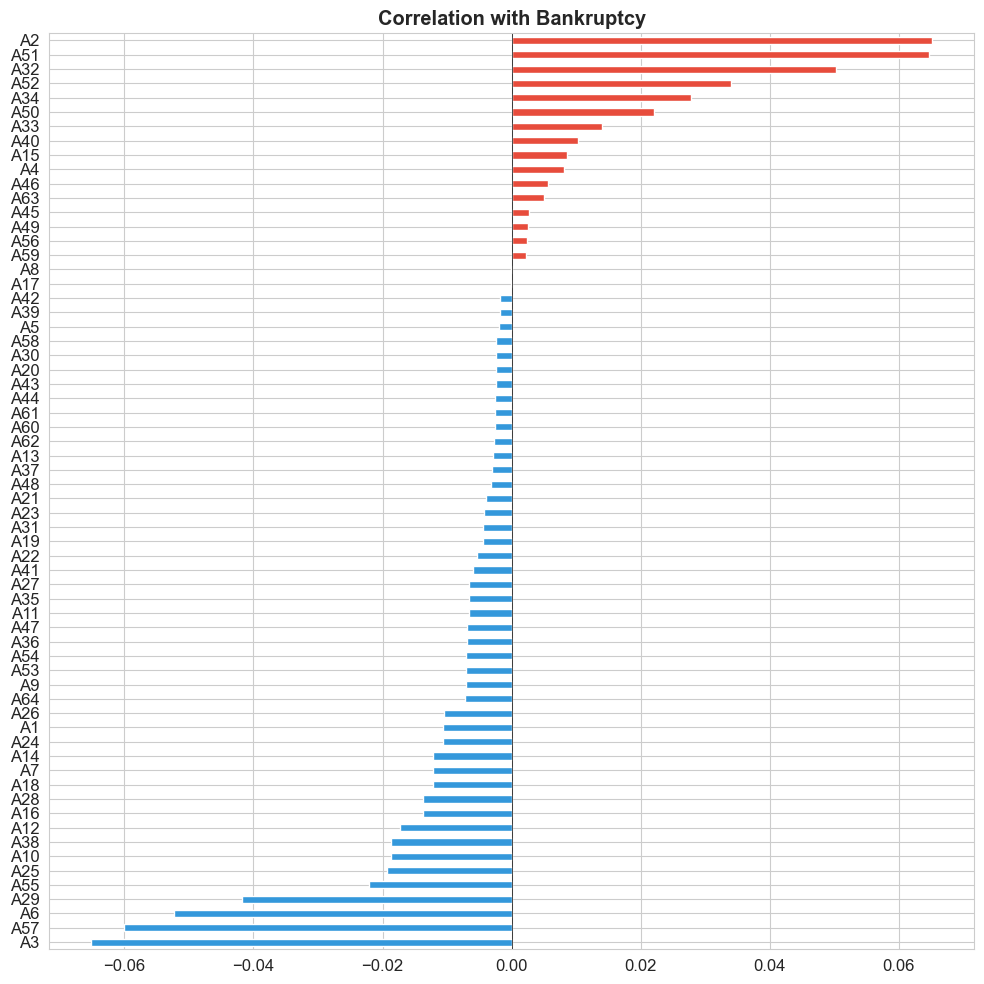

In [43]:
# Correlation with target (top features)
corr_t = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values()
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_t]
corr_t.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Correlation with Bankruptcy', fontweight='bold')
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

---
## Phase 5 — Pre-processing
### 5.1 Information Value

In [44]:
def calc_iv(df, feat, tgt, bins=10):
    d = df[[feat, tgt]].dropna().copy()
    try:
        if d[feat].nunique() > bins: d['b'] = pd.qcut(d[feat], q=bins, duplicates='drop')
        else: d['b'] = d[feat]
        g = d.groupby('b', observed=True)[tgt].agg(['count','sum'])
        g.columns=['total','ev']; g['nev']=g['total']-g['ev']
        te,tne=max(g['ev'].sum(),1),max(g['nev'].sum(),1)
        g['er']=g['ev'].replace(0,0.5)/te; g['ner']=g['nev'].replace(0,0.5)/tne
        g['woe']=np.log(g['ner']/g['er']); g['iv']=(g['ner']-g['er'])*g['woe']
        return g['iv'].sum()
    except: return 0

iv = pd.DataFrame({'Feature': feature_cols, 'IV': [calc_iv(pd.concat([X_train,y_train],axis=1), c, target_col) for c in feature_cols]})
iv = iv.sort_values('IV', ascending=False).head(30)
iv['Strength'] = iv['IV'].apply(lambda x: 'Very Strong' if x>=0.5 else 'Strong' if x>=0.3 else 'Medium' if x>=0.1 else 'Weak' if x>=0.02 else 'Useless')
print('Top 30 by IV:'); print(iv.to_string(index=False))

Top 30 by IV:
Feature       IV    Strength
    A27 0.861983 Very Strong
    A24 0.691636 Very Strong
    A26 0.667406 Very Strong
    A16 0.634288 Very Strong
    A13 0.585618 Very Strong
    A23 0.541970 Very Strong
    A12 0.531866 Very Strong
    A46 0.499317      Strong
    A15 0.484728      Strong
    A31 0.476894      Strong
    A19 0.476034      Strong
     A1 0.462877      Strong
    A14 0.451216      Strong
     A7 0.451216      Strong
    A18 0.451216      Strong
     A6 0.440377      Strong
    A54 0.408812      Strong
    A38 0.405968      Strong
     A4 0.395567      Strong
    A11 0.394497      Strong
     A3 0.381100      Strong
    A45 0.375931      Strong
     A8 0.371532      Strong
    A10 0.371526      Strong
    A53 0.354647      Strong
    A55 0.354444      Strong
     A2 0.350703      Strong
    A25 0.350648      Strong
    A41 0.345982      Strong
    A17 0.337012      Strong


---
## Phase 6 — Modeling

In [45]:
results = {}; colors_p = plt.cm.Set2(np.linspace(0,1,15))
def eval_model(name, mdl, Xtr, Xte, ytr, yte, par='ML'):
    mdl.fit(Xtr, ytr); yp = mdl.predict(Xte)
    if hasattr(mdl,'predict_proba'): ypr = mdl.predict_proba(Xte)[:,1]
    elif hasattr(mdl,'decision_function'): ypr = 1/(1+np.exp(-mdl.decision_function(Xte)))
    else: ypr = yp.astype(float)
    a=accuracy_score(yte,yp); au=roc_auc_score(yte,ypr); g=2*au-1
    f=f1_score(yte,yp,zero_division=0); p=precision_score(yte,yp,zero_division=0); r=recall_score(yte,yp)
    b=brier_score_loss(yte,ypr); fp,tp,_=roc_curve(yte,ypr); ks=max(tp-fp)
    results[name]={'paradigm':par,'model':mdl,'y_pred':yp,'y_prob':ypr,'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':p,'recall':r,'brier':b}
    print(f'  {name}: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')
    return mdl

### 6.1 Paradigm 1 — Classical Econometric

In [46]:
print('=== Paradigm 1: Econometric ===')
eval_model('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

=== Paradigm 1: Econometric ===
  Logistic Regression: Acc=0.6714 AUC=0.6808 Gini=0.3616 KS=0.3270 F1=0.1305 Brier=0.2113


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:


assert X_train_scaled.isna().sum().sum() == 0, "NaN in X_train_scaled"
assert X_test_scaled.isna().sum().sum() == 0, "NaN in X_test_scaled"
assert y_train.isna().sum() == 0, "NaN in y_train"
assert y_test.isna().sum() == 0, "NaN in y_test"

# Probit
Xc = sm.add_constant(X_train_scaled)
Xtc = sm.add_constant(X_test_scaled)
pr = sm.Probit(y_train, Xc).fit(disp=0, maxiter=100)
ypp = pr.predict(Xtc)
ypd = (ypp >= 0.5).astype(int)
a = accuracy_score(y_test, ypd)
au = roc_auc_score(y_test, ypp)
g = 2*au - 1
f = f1_score(y_test, ypd, zero_division=0)
fp, tp, _ = roc_curve(y_test, ypp)
ks = max(tp - fp)
b = brier_score_loss(y_test, ypp)
results['Probit'] = {
    'paradigm': 'Econometric', 'model': pr, 'y_pred': ypd, 'y_prob': ypp,
    'accuracy': a, 'auc': au, 'gini': g, 'ks': ks, 'f1': f,
    'precision': precision_score(y_test, ypd, zero_division=0),
    'recall': recall_score(y_test, ypd),
    'brier': b
}
print(f'  Probit: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')

ValueError: Input contains NaN.

In [ ]:
eval_model('LDA', LinearDiscriminantAnalysis(), X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

#### Altman Z-Score (Fully Computable)

In [ ]:
# Altman Z-Score — FULLY COMPUTABLE for Poland dataset
# Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5
# Mapping:
#   X1 = A3 (working capital / total assets)
#   X2 = A6 (retained earnings / total assets)
#   X3 = A7 (EBIT / total assets)
#   X4 = A8 (book value of equity / total liabilities) — proxy for MV/BV
#   X5 = A9 (sales / total assets)

z_score = (1.2 * X_test['A3'] +
           1.4 * X_test['A6'] +
           3.3 * X_test['A7'] +
           0.6 * X_test['A8'] +
           1.0 * X_test['A9'])

# Classify: Z < 1.81 = Distress, Z > 2.99 = Safe, 1.81-2.99 = Grey Zone
z_pred = (z_score < 1.81).astype(int)
z_prob = 1 / (1 + np.exp(z_score - 1.81))  # Sigmoid around cutoff

a = accuracy_score(y_test, z_pred)
au = roc_auc_score(y_test, z_prob)
g = 2*au - 1
f = f1_score(y_test, z_pred, zero_division=0)
b = brier_score_loss(y_test, z_prob)
fpr_z, tpr_z, _ = roc_curve(y_test, z_prob)
ks = max(tpr_z - fpr_z)

results['Altman Z-Score'] = {
    'paradigm': 'Econometric', 'model': None, 'y_pred': z_pred, 'y_prob': z_prob,
    'accuracy': a, 'auc': au, 'gini': g, 'ks': ks,
    'f1': f, 'precision': precision_score(y_test, z_pred, zero_division=0),
    'recall': recall_score(y_test, z_pred, zero_division=0), 'brier': b
}
print(f'  Altman Z-Score: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')
print(f'  NOTE: X4 uses book value of equity/liabilities as proxy for market value.')

# Z-Score distribution
fig, ax = plt.subplots(figsize=(10, 5))
z_safe = z_score.clip(-10, 20)
ax.hist(z_safe[y_test==0], bins=50, alpha=0.6, label='Not Bankrupt', color='#2ecc71', density=True)
ax.hist(z_safe[y_test==1], bins=50, alpha=0.6, label='Bankrupt', color='#e74c3c', density=True)
ax.axvline(1.81, color='red', ls='--', label='Distress Zone (< 1.81)')
ax.axvline(2.99, color='green', ls='--', label='Safe Zone (> 2.99)')
ax.set_xlabel('Altman Z-Score'); ax.set_title('Z-Score Distribution', fontweight='bold')
ax.legend(); ax.set_xlim([-5, 15])
plt.tight_layout(); plt.show()

### 6.2 Paradigm 2 — Machine Learning

In [ ]:
print('=== Paradigm 2: ML ===')
eval_model('XGBoost', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss', verbosity=0), X_train, X_test, y_train, y_test)
eval_model('LightGBM', lgb.LGBMClassifier(n_estimators=200, max_depth=6, is_unbalance=True, random_state=42, verbose=-1), X_train, X_test, y_train, y_test)
eval_model('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test)
eval_model('SVM', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled, y_train, y_test)
eval_model('kNN', KNeighborsClassifier(n_neighbors=7, n_jobs=-1), X_train_scaled, X_test_scaled, y_train, y_test)
eval_model('CART', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42), X_train, X_test, y_train, y_test)
eval_model('MLP', MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42, early_stopping=True), X_train_scaled, X_test_scaled, y_train, y_test)

### 6.3 Paradigm 3 — Structural & Market-Based

> **NOT APPLICABLE.** The dataset contains only balance sheet-derived ratios.
> No stock prices, market capitalization, or equity volatility data.
> Polish companies in this dataset are not necessarily publicly listed.
> Merton/KMV require market equity data for listed entities.

### 6.4 Paradigm 4 — Dynamic Stochastic

> **Markov Chains**: NOT APPLICABLE — the 5 ARFF files are separate cross-sections,
> not panel data tracking the same firms over time. Each file contains different companies
> observed at different horizons before bankruptcy.
>
> **Cox PH (Survival Analysis)**: PARTIALLY APPLICABLE — we construct a pseudo-survival
> analysis by combining the 5 time horizons, treating the horizon (1–5 years) as the
> "time-to-event" variable.

#### Cox PH — Cross-Horizon Survival Approximation

In [ ]:
try:
    from lifelines import CoxPHFitter
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifelines'])
    from lifelines import CoxPHFitter

# Combine all horizons with a 'duration' column
frames = []
for horizon, df_h in dfs.items():
    temp = df_h.copy()
    temp.columns = [rename_map.get(c, c) for c in temp.columns]
    temp['duration'] = horizon  # years before bankruptcy
    frames.append(temp)

df_surv = pd.concat(frames, ignore_index=True)

# Clean
surv_feats = ['A1', 'A3', 'A7', 'A9', 'A29']
df_surv_clean = df_surv[surv_feats + ['duration', 'class']].dropna()
df_surv_clean = df_surv_clean.replace([np.inf, -np.inf], np.nan).dropna()

# Clip outliers for convergence
for c in surv_feats:
    q1, q99 = df_surv_clean[c].quantile(0.01), df_surv_clean[c].quantile(0.99)
    df_surv_clean[c] = df_surv_clean[c].clip(q1, q99)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_surv_clean, duration_col='duration', event_col='class')
cph.print_summary()
print(f'\nConcordance Index: {cph.concordance_index_:.4f}')
print('\nCAVEAT: This is an approximation. The "duration" variable is the prediction horizon,')
print('not actual time-to-default for individual companies.')

---
## Phase 7 — Evaluation on Test Set

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for i, (n, r) in enumerate(results.items()):
    fp, tp, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fp, tp, label=f"{n} (AUC={r['auc']:.4f})", color=colors_p[i%len(colors_p)], linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.5); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontsize=16, fontweight='bold'); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
n=len(results); nc=4; nr=(n+nc-1)//nc
fig,axes=plt.subplots(nr,nc,figsize=(5*nc,4*nr)); axes=axes.flatten()
for i,(n,r) in enumerate(results.items()):
    cm=confusion_matrix(y_test,r['y_pred'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i],xticklabels=['Safe','Bankrupt'],yticklabels=['Safe','Bankrupt'])
    axes[i].set_title(n,fontweight='bold',fontsize=9)
for j in range(i+1,len(axes)): axes[j].set_visible(False)
plt.suptitle('Confusion Matrices',fontsize=14,fontweight='bold',y=1.02); plt.tight_layout(); plt.show()

In [ ]:
for n,r in results.items():
    print(f'\n=== {n} ({r["paradigm"]}) ==='); print(classification_report(y_test,r['y_pred'],target_names=['Safe','Bankrupt']))

### Cross-Horizon Comparison (1–5 years)

In [ ]:
# Train the best model on each horizon and compare AUC
horizon_results = {}
for h in range(1, 6):
    dh = dfs[h].copy()
    dh.columns = [rename_map.get(c, c) for c in dh.columns]
    # Clean
    fc = [c for c in dh.columns if c != target_col]
    dh[fc] = dh[fc].replace([np.inf, -np.inf], np.nan)
    dh[fc] = dh[fc].fillna(dh[fc].median())
    Xh = dh[fc]; yh = dh[target_col]
    Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=0.3, random_state=42, stratify=yh)
    m = xgb.XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=(yh_tr==0).sum()/(yh_tr==1).sum(),
                          random_state=42, eval_metric='logloss', verbosity=0)
    m.fit(Xh_tr, yh_tr)
    yp = m.predict_proba(Xh_te)[:, 1]
    au = roc_auc_score(yh_te, yp)
    horizon_results[h] = au
    print(f'  {h}-year horizon: AUC = {au:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(horizon_results.keys()), list(horizon_results.values()), 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Prediction Horizon (years before bankruptcy)')
ax.set_ylabel('AUC (XGBoost)')
ax.set_title('Model Performance Degradation Across Horizons', fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('\nAs expected, prediction accuracy DECREASES as the horizon increases.')
print('Financial indicators are more predictive of imminent bankruptcy than distant failure.')

---
## Phase 8 — Model Calibration

In [ ]:
fig,ax=plt.subplots(figsize=(10,7)); ax.plot([0,1],[0,1],'k--',label='Perfect')
for i,(n,r) in enumerate(results.items()):
    try: pt,pp=calibration_curve(y_test,r['y_prob'],n_bins=10); ax.plot(pp,pt,marker='o',label=n,color=colors_p[i%len(colors_p)])
    except: pass
ax.set_xlabel('Predicted'); ax.set_ylabel('Observed'); ax.set_title('Calibration Curves',fontweight='bold')
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

In [ ]:
print('Brier Score:')
for n,r in sorted(results.items(),key=lambda x:x[1]['brier']): print(f"  {n:30s} Brier={r['brier']:.6f}")

---
## Phase 9 — Post-Model Calibration

In [ ]:
bml=max([k for k,v in results.items() if v['paradigm']=='ML'],key=lambda k:results[k]['auc'])
print(f'Post-calibration for: {bml}')
us=bml in ['SVM','kNN','MLP']; Xtr=X_train_scaled if us else X_train; Xte=X_test_scaled if us else X_test
for m,l in [('sigmoid','Platt'),('isotonic','Isotonic')]:
    try:
        base=results[bml]['model'].__class__(**results[bml]['model'].get_params())
        c=CalibratedClassifierCV(base,method=m,cv=3); c.fit(Xtr,y_train)
        yp=c.predict_proba(Xte)[:,1]; print(f'  {l}: Brier={brier_score_loss(y_test,yp):.6f} (orig: {results[bml]["brier"]:.6f})')
    except Exception as e: print(f'  {l}: Failed — {e}')

---
## Phase 10 — Interpretability (SHAP)

In [ ]:
tm={k:v for k,v in results.items() if k in ['XGBoost','LightGBM','Random Forest','CART']}
bt=max(tm.keys(),key=lambda k:tm[k]['auc']); print(f'SHAP: {bt}')
exp=shap.TreeExplainer(results[bt]['model'])
Xs=X_test.sample(min(500,len(X_test)),random_state=42)
sv=exp.shap_values(Xs)
if isinstance(sv,list): sv=sv[1]
plt.figure(figsize=(12,10)); shap.summary_plot(sv,Xs,plot_type='bar',show=False,max_display=20)
plt.title(f'SHAP Importance — {bt}',fontweight='bold'); plt.tight_layout(); plt.show()

In [ ]:
plt.figure(figsize=(12,10)); shap.summary_plot(sv,Xs,show=False,max_display=20)
plt.title(f'SHAP Beeswarm — {bt}',fontweight='bold'); plt.tight_layout(); plt.show()

---
## Phase 11 — Final Comparative Summary

In [ ]:
comp=pd.DataFrame({k:[results[m][k] for m in results] for k in ['accuracy','auc','gini','ks','f1','precision','recall','brier']})
comp.insert(0,'Model',list(results.keys())); comp.insert(1,'Paradigm',[results[m]['paradigm'] for m in results])
comp=comp.sort_values('auc',ascending=False).reset_index(drop=True); comp.index+=1; comp.index.name='Rank'
print('=== FINAL COMPARISON — Poland Bankruptcy (1-year horizon) ==='); print(comp.to_string())

In [ ]:
fig,ax=plt.subplots(figsize=(10,6))
pc={'Econometric':'#e74c3c','ML':'#3498db'}; bc=[pc.get(results[m]['paradigm'],'#95a5a6') for m in comp['Model']]
bars=ax.barh(comp['Model'],comp['auc'],color=bc); ax.set_xlabel('AUC')
ax.set_title('AUC Comparison',fontweight='bold'); ax.set_xlim([0.4,max(comp['auc'])+0.05]); ax.invert_yaxis()
for b,v in zip(bars,comp['auc']): ax.text(v+0.005,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=9)
plt.tight_layout(); plt.show()

### Discussion

1. **Altman Z-Score**: Fully computable with direct ratio mappings (A3, A6, A7, A8, A9). X4 uses book value
   as proxy for market value (Polish private companies). Performance compared against ML models.

2. **Cross-Horizon Degradation**: AUC decreases from 1-year to 5-year horizon, confirming that financial
   indicators lose predictive power for distant bankruptcy events.

3. **Cox PH**: Implemented as a cross-horizon approximation, treating the prediction horizon as time-to-event.

4. **Class Imbalance**: Handled with class_weight='balanced' and scale_pos_weight.

---
## End of Analysis